# Imbalanced MC Timeseries Study


## 1) Imports y configuracion


In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error
from pathlib import Path
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.impute import IterativeImputer
from missforest import MissForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import LinearSVC
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Placeholders para clases de imblearn (si no está instalado, se mantienen como None)
# Esto permite que el notebook se ejecute sin errores incluso si imblearn no está disponible, aunque solo se evaluará la estrategia baseline en ese caso.
# Si imblearn está instalado, estas variables se sobrescribirán con las clases correspondientes.


RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# Placeholders para variables que se construyen mas adelante en celdas EDA.
# Evita falsos positivos del analizador estatico en notebooks por orden de ejecucion de celdas.
multilabel_targets = pd.DataFrame()
time_series_metrics = {}
base_dir = Path("datasets")

## 2) Loading

In [13]:
doors_registry = pd.read_csv(base_dir / "registry.csv")
door_catalog = pd.read_csv(base_dir / "catalog.csv")
maintenance_history = pd.read_csv(base_dir/ "history.csv")

print("doors_registry:", doors_registry.shape)
print("door_catalog:", door_catalog.shape)
print("maintenance_history:", maintenance_history.shape)

doors_registry: (504, 8)
door_catalog: (18, 7)
maintenance_history: (504, 7)


## 3) Exploratory Analysis ( EDA )

In [14]:
# Vista rapida
print("First rows of each table:")
display(doors_registry.head(3))
display(maintenance_history.head(3))
display(door_catalog.head(3))

print("\nData types:")
print("Door registry types of data:")
print(doors_registry.dtypes)
print("\nMaintenance history types of data:")
print(maintenance_history.dtypes)
print("\nDoor catalog types of data:")
print(door_catalog.dtypes)


First rows of each table:


,door_id,country_id,country_name,door_type,usage_scenario,installation_environment,customer_type,context_criticality_id
0,P-ES-000001,ES,Spain,ECOline Pedestrian,low,Office,B2B,CC01
1,P-ES-000002,ES,Spain,ECOline Pedestrian,low,Office,B2B,CC01
2,P-ES-000003,ES,Spain,ECOline Pedestrian,low,Office,B2B,CC01


,door_id,last_maintenance_date,maintenance_type,number_of_past_failures,days_since_last_failure,days_to_next_failure,failed_next_30_days
0,P-ES-000001,2024-12-11,Inspection,0.0,569.0,NaN,NaN
1,P-ES-000002,2024-11-06,Preventive,0.0,715.0,NaN,NaN
2,P-ES-000003,2024-07-10,Inspection,3.0,0.0,NaN,NaN


,door_type,usage_scenario,installation_environment,criticality_level,operational_complexity,maintenance_intensity,estimated_cycles_day
0,ECOline Pedestrian,low,Office,medium,medium,low,120.0
1,ECOline Pedestrian,moderate,Office,medium,medium,medium,400.0
2,ECOline Pedestrian,intensive,Office,high,medium,high,800.0



Data types:
Door registry types of data:
door_id                     object
country_id                  object
country_name                object
door_type                   object
usage_scenario              object
installation_environment    object
customer_type               object
context_criticality_id      object
dtype: object

Maintenance history types of data:
door_id                     object
last_maintenance_date       object
maintenance_type            object
number_of_past_failures    float64
days_since_last_failure    float64
days_to_next_failure       float64
failed_next_30_days        float64
dtype: object

Door catalog types of data:
door_type                    object
usage_scenario               object
installation_environment     object
criticality_level            object
operational_complexity       object
maintenance_intensity        object
estimated_cycles_day        float64
dtype: object


In [16]:
# Resumen de missing values con conteo, porcentaje y unicos para cada tabla.
# Esto ayuda a priorizar variables para imputacion y entender la calidad de los datos.
# La funcion `missing_table_direct` imprime un resumen formateado directamente en consola, lo que
def missing_table_direct(df, name):
    print(f"\nMissing summary : {name}")
    print(f"{'Columna':<30} | {'Nulos':<10} | {'% Nulos':<10} | {'Únicos':<10}")
    # Itera sobre cada columna del dataframe y calcula el conteo de nulos, el porcentaje de nulos y el número de valores únicos (sin contar nulos).
    for col in df.columns:
        m_count = df[col].isna()
        m_count = m_count.sum()
        m_pct = (df[col].isna().mean() * 100).round(2)
        # Calcula el número de valores únicos (sin contar nulos).
        n_unique = df[col]
        n_unique = n_unique.nunique(dropna=True)
        # Imprime cada fila del resumen con formato
        # Solo imprime el nombre de la columna, el conteo de nulos, el porcentaje de nulos y el número de valores únicos (sin contar nulos).
        print(f"{col:<30} | {m_count:<10} | {m_pct:<10} | {n_unique:<10}")
missing_table_direct(doors_registry, "doors_registry")






Missing summary : doors_registry
Columna                        | Nulos      | % Nulos    | Únicos    
door_id                        | 0          | 0.0        | 504       
country_id                     | 0          | 0.0        | 20        
country_name                   | 0          | 0.0        | 20        
door_type                      | 0          | 0.0        | 3         
usage_scenario                 | 0          | 0.0        | 3         
installation_environment       | 0          | 0.0        | 6         
customer_type                  | 0          | 0.0        | 2         
context_criticality_id         | 0          | 0.0        | 5         


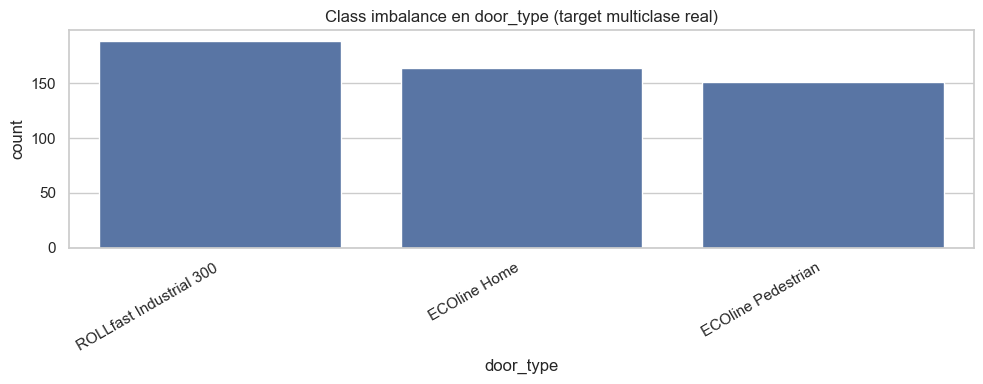

Imbalance ratio door_type: 1.25


In [17]:
# Distribucion de la variable objetivo principal (multiclase real)
# Primer chequeo de imbalance del target real para anticipar sesgos de entrenamiento.
plt.figure(figsize=(10, 4))
door_counts = doors_registry["door_type"].value_counts()
sns.barplot(x=door_counts.index, y=door_counts.values)
plt.xticks(rotation=30, ha="right")
plt.title("Class imbalance en door_type (target multiclase real)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

max_doors = door_counts.max()
max_min_doors = max(door_counts.min(), 1)
imbalance_ratio = max_doors / max_min_doors
print(f"Imbalance ratio door_type: {round(imbalance_ratio,2)}")


### Interpretation Imbalance Ratio
El gráfico muestra la frecuencia de cada tipo de puerta. El ratio calculado indica cuántas veces es mayor la clase más frecuente respecto a la menos frecuente. Valores altos sugieren un marcado desbalanceo que podría requerir técnicas de remuestreo (como SMOTE o Under-sampling) antes de entrenar el modelo.


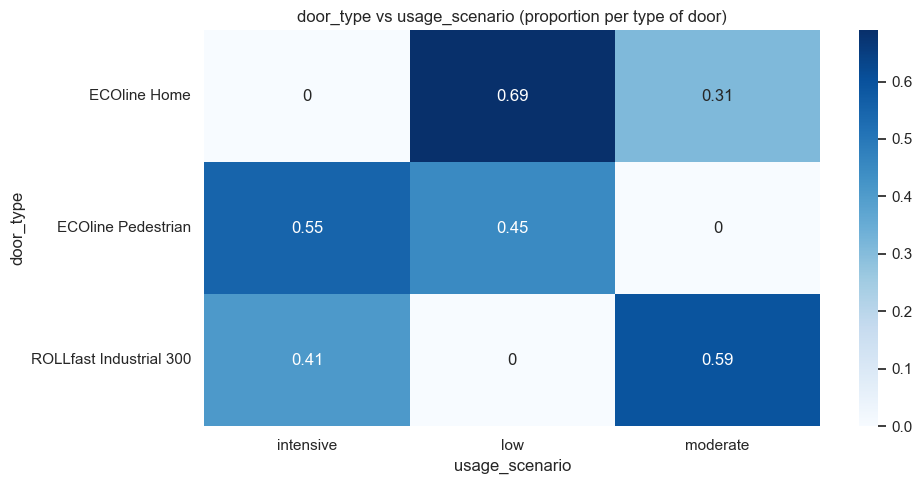

In [18]:
# Analisis explainability temprano: asociaciones simples entre categoricas clave
# El heatmap normalizado por fila ayuda a interpretar la mezcla de escenarios por tipo de puerta.
# Si se observa que ciertos tipos de puertas están fuertemente asociados a escenarios específicos, esto puede ser una señal importante para la interpretabilidad del modelo y para entender el contexto operativo de cada tipo de puerta.
# Agrupar por tipo de puerta y contar escenarios de uso para cada tipo.
ct = (doors_registry.groupby("door_type")["usage_scenario"])
# Normalizamos por fila para ver proporciones dentro de cada tipo de puerta.

ct = ct.value_counts(normalize=True).unstack(fill_value=0)
plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("door_type vs usage_scenario (proportion per type of door)")
plt.tight_layout()
plt.show()


In [19]:
# Join temprano para EDA integrado
# Unificamos etiquetas para que el merge con catalog no pierda filas por diferencias semanticas.
doors_registry["installation_environment"] = doors_registry["installation_environment"].replace(
    "Community", "Residential Community"
)

# Este dataframe combinado es la base para analizar riesgo, imputacion y proxy targets.
eda_merged = doors_registry.merge(maintenance_history, on="door_id", how="left")

eda_merged = eda_merged.merge(
    door_catalog,
    on=["door_type", "usage_scenario", "installation_environment"],
    how="left"
)

# Fecha de corte fija para tener calculos reproducibles entre ejecuciones. Errors="coerce" fuerza la conversión en cambio de lanzar una excepción
eda_merged["last_maintenance_date"] = pd.to_datetime(eda_merged["last_maintenance_date"], errors="coerce")
snapshot_date = pd.Timestamp("2025-01-01")
eda_merged["days_since_maintenance"] = (snapshot_date - eda_merged["last_maintenance_date"]).dt.days


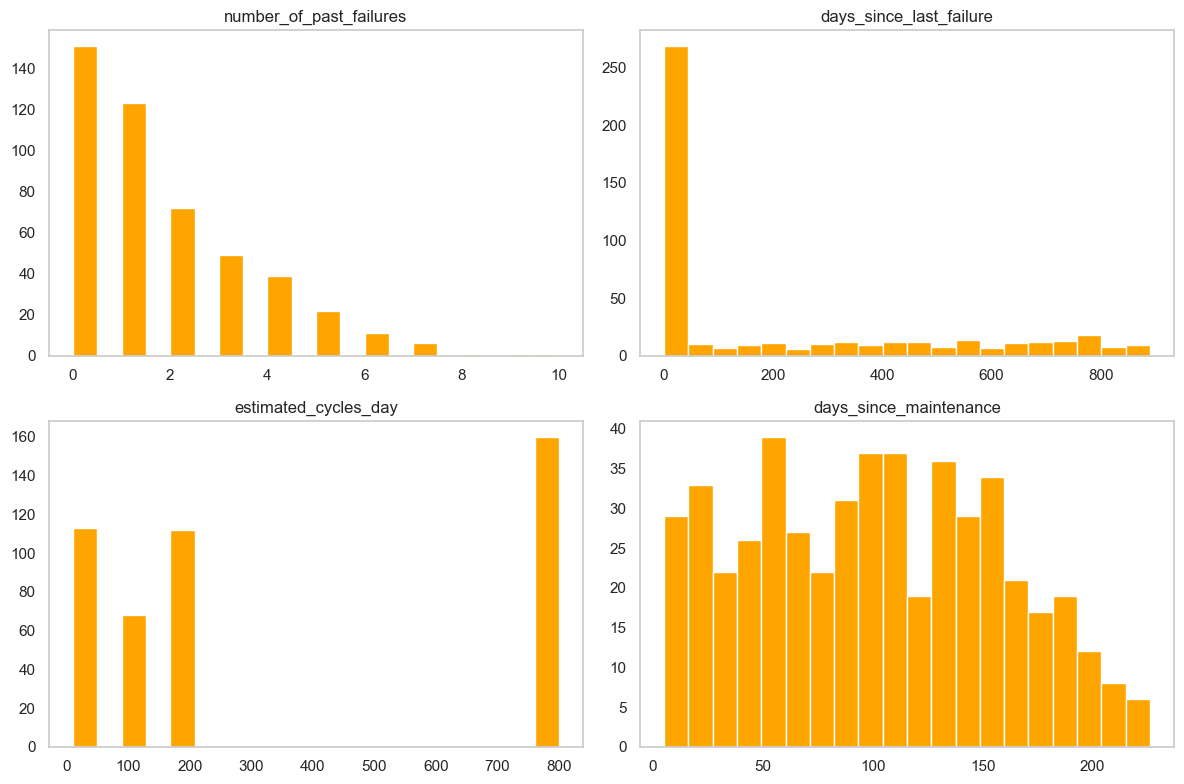

In [20]:
# Distribuciones numericas importantes para imputacion y riesgo
num_for_eda = [
    "number_of_past_failures",
    "days_since_last_failure",
    "estimated_cycles_day",
    "days_since_maintenance",
]

eda_merged[num_for_eda].hist(bins=20,
                         figsize=(12, 8),
                            color="orange",
                             grid=False)
plt.tight_layout()
plt.show()


### Interpretación de las distribuciones numéricas
- Comprender la forma de estas distribuciones es clave para evaluar el riesgo y decidir la estrategia de imputación de valores nulos.
- Si se observa alta asimetría (skewness) o presencia notable de valores atípicos, los métodos de imputación basados en la media pueden introducir sesgos.
- En esos casos, técnicas iterativas multivariantes (como MICE, MissForest o KNN) suelen ser más robustas para preservar la distribución original de la información operativa.


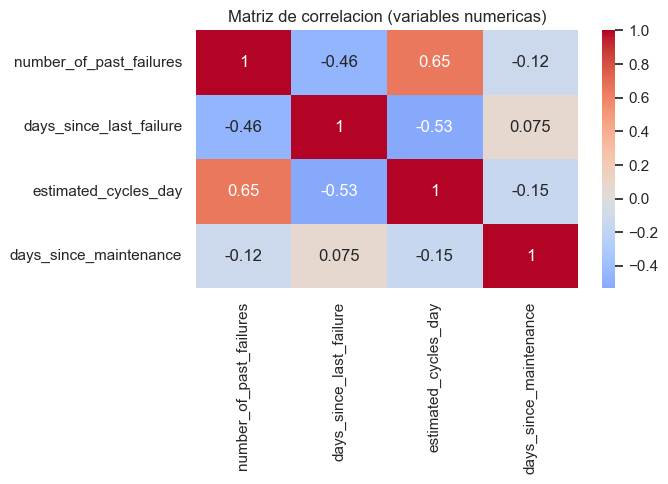

In [10]:
# Correlacion para apoyar decisiones de explainability
# No implica causalidad, pero orienta sobre variables con señal conjunta fuerte.
corr_cols = ["number_of_past_failures", "days_since_last_failure", "estimated_cycles_day", "days_since_maintenance"]
plt.figure(figsize=(7, 5))
sns.heatmap(eda_merged[corr_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlacion (variables numericas)")
plt.tight_layout()
plt.show()


### 3.6) Time series analysis and forecasting (baseline)
Usamos `last_maintenance_date` para crear una serie temporal mensual de actividad de mantenimiento.
Luego comparamos dos baselines simples de forecasting (naive y rolling mean) para tener una referencia temporal interpretable.


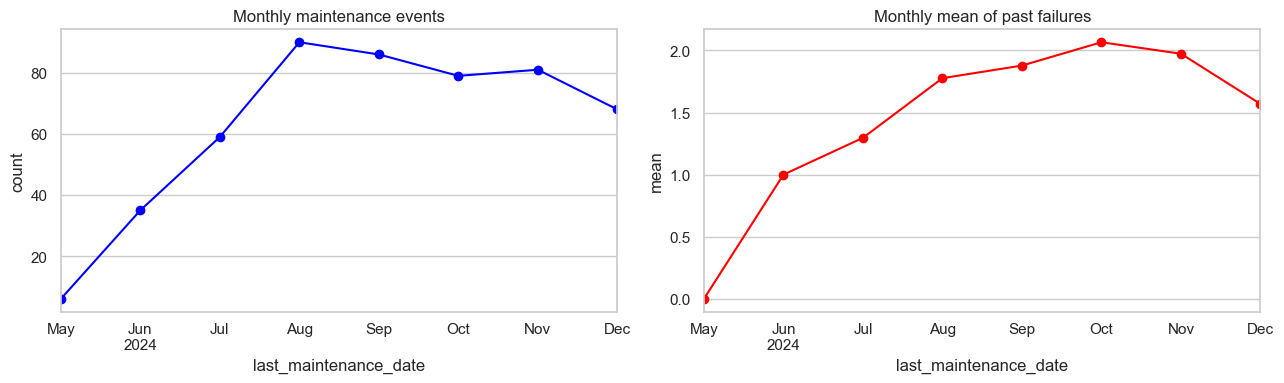

In [21]:
# Serie temporal mensual de eventos de mantenimiento.
ts_history = maintenance_history[["last_maintenance_date", "number_of_past_failures"]].copy()

ts_history["last_maintenance_date"] = pd.to_datetime(ts_history["last_maintenance_date"])
ts_history = ts_history.dropna(subset=["last_maintenance_date"]).sort_values("last_maintenance_date")


# Set index convierte la fecha en el indice
#Resample agrupa la serie temporal por mes
#Size cuenta cuantos mantenimientos ha habido en cada mes
monthly_events = (
    ts_history.set_index("last_maintenance_date")
    .resample("MS")
    .size()
    .rename("maintenance_events"))
#Aqui hace lo mismo pero en cambio de un conteo, calcula la media
monthly_failures_mean = (
    ts_history.set_index("last_maintenance_date")["number_of_past_failures"]
    .resample("MS")
    .mean()
    .rename("avg_past_failures")


)
#Junta las dos series temporales horizontalmente en un unico dataframe
monthly_ts = pd.concat([monthly_events, monthly_failures_mean], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
#Primer plot sobre el primer panel con puntos marcados en azul
monthly_ts["maintenance_events"].plot(ax=axes[0], marker="o", color="blue")
axes[0].set_title("Monthly maintenance events")
axes[0].set_ylabel("count")

# Segundo gráfico sobre el segundo panel con puntos en rojo
monthly_ts["avg_past_failures"].plot(ax=axes[1], marker="o", color="red")
axes[1].set_title("Monthly mean of past failures")
axes[1].set_ylabel("mean")

plt.tight_layout()
plt.show()


,model,mae,rmse
0,naive_last_value,6.5,7.905694
1,rolling_mean_3,10.5,12.349089


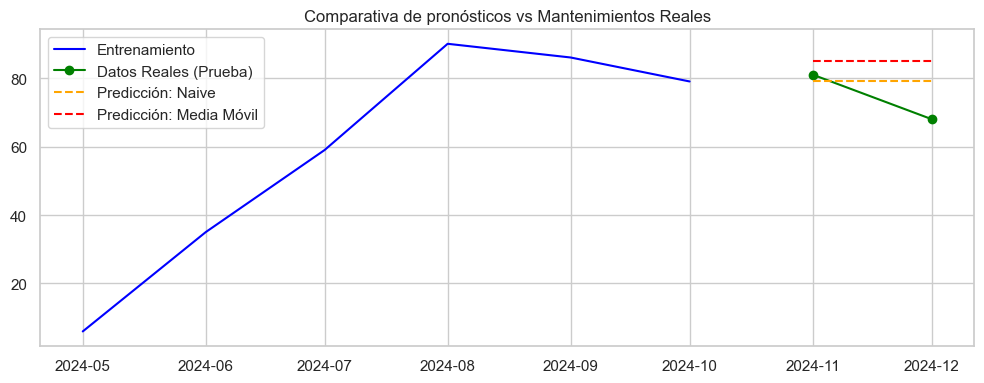

In [22]:
#Extraemos la columna y elimiinamos cualquier valor nulo
series = monthly_ts["maintenance_events"].dropna()

#Inicializamos un diccionario vacio para guardar las metricas del mejor modelo
time_series_metrics = {}
train_ts, test_ts = train_test_split(series, test_size=0.2, shuffle=False)

#Verificamos si hay al menos 8 meses de datos, si no los hay, detenemos la evaluacion
if len(series) < 8:
    print("La serie temporal es demasiado corta (menos de 8 meses) para evaluar métricas.")
else:

    # # Divide secuencialmente la serie temporal conservando el orden temporal
    train_ts, test_ts = train_test_split(series, test_size=0.2, shuffle=False)


    # Obtenemos el ultimo valor del conjunto de entrenamiento
    last_known_value = train_ts.iloc[-1]
    #Creamos un pronostico Naive, y asumimos que todos los valores futuros seran identicos a ese ultimo valor conocido
    naive_pred = pd.Series(last_known_value, index=test_ts.index)

    # Calculamos el promedio de los ultimos tres meses del conjunto de entrenamiento
    last_3_months_mean = train_ts.tail(3).mean()
    #Creamos el pronostico de media movil usando ese promedio para todos los periodos futuros
    rolling_pred = pd.Series(last_3_months_mean, index=test_ts.index)

    #Error absoluto medio y la raiz del error cuadrado medio comparando con los datos
    naive_mae = mean_absolute_error(test_ts, naive_pred)
    naive_rmse = float(np.sqrt(mean_squared_error(test_ts, naive_pred)))
    #Calcula las mismas metricas pero para el pronostico de media movil
    rolling_mae = mean_absolute_error(test_ts, rolling_pred)
    rolling_rmse = float(np.sqrt(mean_squared_error(test_ts, rolling_pred)))

    # Almacenamos los resultados y los ordenamos de menor a mayor error absoluto
    resultados = [
        {"model": "naive_last_value", "mae": naive_mae, "rmse": naive_rmse},
        {"model": "rolling_mean_3", "mae": rolling_mae, "rmse": rolling_rmse},
    ]
    ts_results = pd.DataFrame(resultados).sort_values("mae")
    #Display de la tabla
    display(ts_results)

    # Extraemos la fila correspondiente al modelo con menor error absoluto medio
    mejor_modelo = ts_results.iloc[0]
    #Guardamos en el diccionario que inicializamos al principio, y le añadimos el nombre,
    #los errores y el tamaño de los conjuntos de datos.
    time_series_metrics = {
        "best_model": mejor_modelo["model"],
        "mae": float(mejor_modelo["mae"]),
        "rmse": float(mejor_modelo["rmse"]),
        "n_train": len(train_ts),
        "n_test": len(test_ts),
    }

    # Lo ploteamos
    plt.figure(figsize=(10, 4))

    # Datos históricos y reales
    plt.plot(train_ts.index, train_ts.values, label="Entrenamiento", color="blue")
    plt.plot(test_ts.index, test_ts.values, label="Datos Reales (Prueba)", color="green", marker="o")

    # Líneas de nuestras predicciones
    plt.plot(test_ts.index, naive_pred.values, label="Predicción: Naive", linestyle="--", color="orange")
    plt.plot(test_ts.index, rolling_pred.values, label="Predicción: Media Móvil", linestyle="--", color="red")

    plt.title("Comparativa de pronósticos vs Mantenimientos Reales")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4) Data Transformation
In this step we will perform the necessary data transformations to prepare our dataset for modeling. This includes handling missing values, encoding categorical variables, and creating new features if necessary.

In [23]:

# In doors_registry, some doors are labeled as Community. How ever in  door_type_usage_catalog, that same environment is labeled as Residential Community.
doors_registry["installation_environment"] = doors_registry["installation_environment"].replace("Community", "Residential Community")


### 4.1) Join

In [24]:
merged_data = doors_registry.merge(maintenance_history, on='door_id', how='left')

# Join with Catalog on the three environment keys
final_dataset = merged_data.merge(
    door_catalog,
    on=['door_type','usage_scenario', 'installation_environment'],
    how='left'
)
# Drop unnecessary columns
# Remove the cols : days_to_next_failure,failed_next_30_days becuase it has 100 % of missing data
final_dataset.drop(
    columns=['door_id','country_id',"days_to_next_failure", "failed_next_30_days" , "last_maintenance_date" ],
    inplace=True)


### 4.2) Dependency analysis and feature selection
In this step we will analyze the dependencies between our features to identify any strong correlations or associations. This will help us to select the most relevant features for our model and to avoid multicollinearity issues. We will use correlation analysis for numerical features and Cramér's V for categorical features to measure the strength of associations. Based on the results, we will decide which features to keep, which ones to drop, and if any feature engineering is needed to create new features that may capture important information for our classification task. The goal is to have a set of features that are informative, non-redundant, and suitable for training our machine learning model effectively.

Numerical cols: 3
Categorical cols: 9


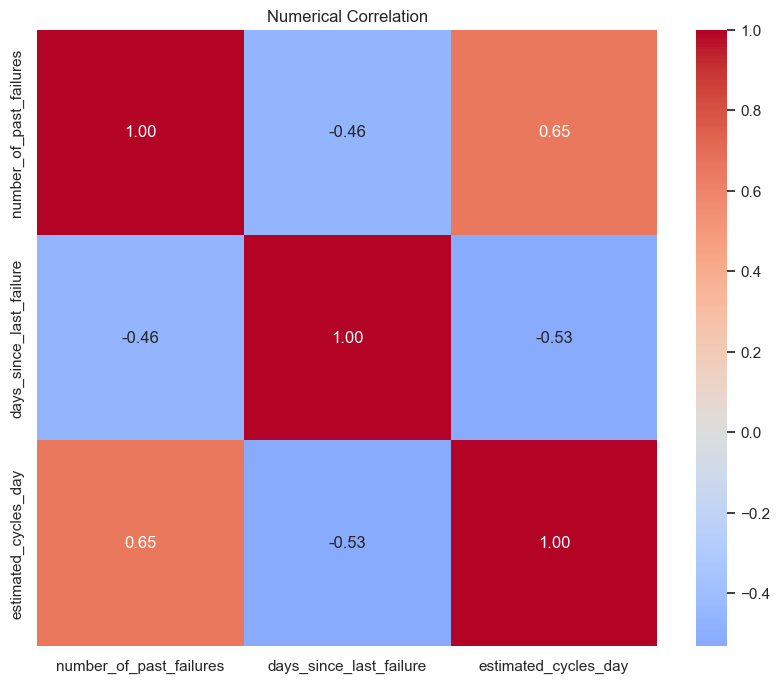

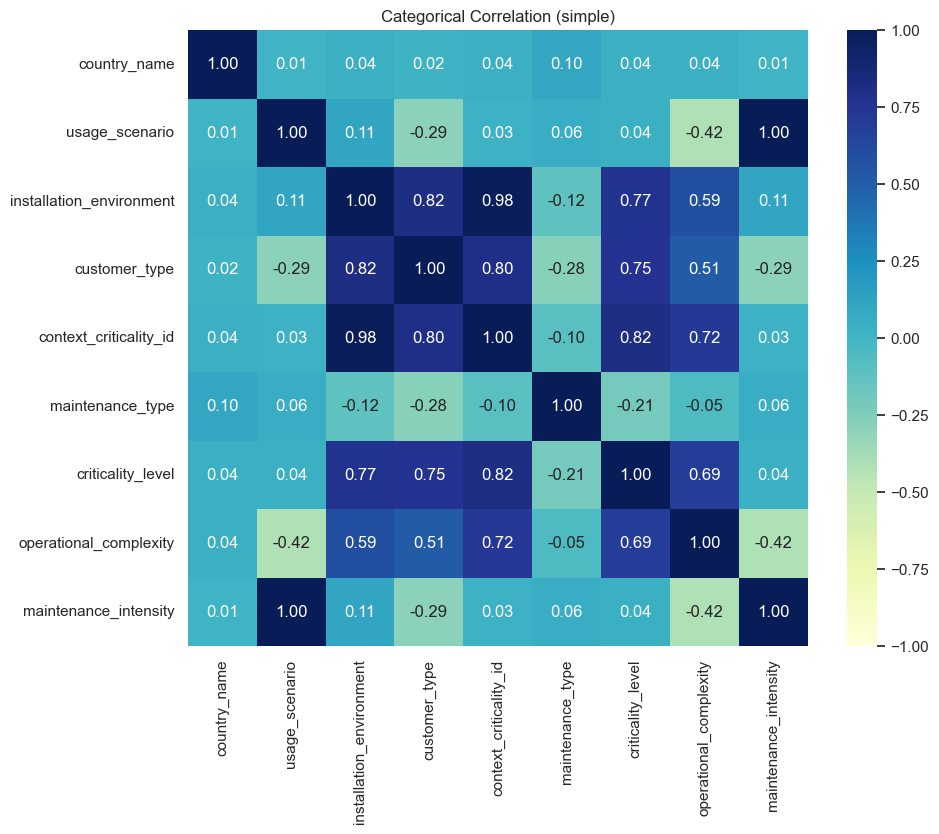

Review these two heatmaps manually and choose columns to keep/drop.


In [25]:

target_col = "door_type"
feature_df = final_dataset.drop(columns=[target_col], errors="ignore")

num_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = feature_df.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns.tolist()

print(f"Numerical cols: {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")

# 1) Numerical correlation heatmap with values
if num_cols:
    num_corr = feature_df[num_cols].corr().round(2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Numerical Correlation")
    plt.show()


# 2) Categorical correlation heatmap (simple version)
if cat_cols:
    cat_df = feature_df[cat_cols].copy()

    # Convert each categorical column to integer codes
    for col in cat_cols:
        cat_df[col] = pd.factorize(cat_df[col])[0]

    cat_corr = cat_df.corr().round(2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cat_corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
    plt.title("Categorical Correlation (simple)")
    plt.show()

print("Review these two heatmaps manually and choose columns to keep/drop.")

In [26]:
drop_features = [
    'context_criticality_id',
    'criticality_level',
    'customer_type',
    'installation_environment',
    'maintenance_intensity',
    'operational_complexity',
    'usage_scenario']
final_dataset = final_dataset.drop(columns=drop_features, errors="ignore")

In [27]:
final_dataset.head()

,country_name,door_type,maintenance_type,number_of_past_failures,days_since_last_failure,estimated_cycles_day
0,Spain,ECOline Pedestrian,Inspection,0.0,569.0,120.0
1,Spain,ECOline Pedestrian,Preventive,0.0,715.0,120.0
2,Spain,ECOline Pedestrian,Inspection,3.0,0.0,120.0
3,Spain,ECOline Pedestrian,Inspection,0.0,1.0,120.0
4,Spain,ECOline Pedestrian,Inspection,2.0,2.0,120.0


### 4.2) Encode categorical variables

In [28]:

target_col = "door_type"
X = final_dataset.drop(columns=[target_col])
y = final_dataset[target_col]

cat_cols = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()


X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)


### 4.3) Split train - test

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(403, 25) (403,)
(101, 25) (101,)


### 4.4 ) Handle missing values
Because we have more than one variable with null values , we will use Multivariate imputation methods . This are the different techniques that we will use , and see which one works better for our datasets :

   - Multivariate Imputation by Chained Equations (MICE): This technique models each feature with missing values as a function of other features and iteratively imputes missing values. It can capture complex relationships and is suitable for both numerical and categorical data but can be computationally intensive.

   - MissForest Imputation: This method uses Random Forest models in an iterative way to impute missing values. For each column with missing data, it trains a model using the other columns as predictors and then fills the missing entries. It works well with mixed data types (numerical and categorical), captures non-linear relationships, and is often more accurate than simple imputation methods. However, it can be computationally expensive on larger datasets.


   - K-Nearest Neighbors (KNN) Imputation: This method imputes missing values based on the values of the nearest neighbors in the feature space. It can capture complex relationships between features but can be computationally expensive for large datasets.




In [31]:
def mic_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_mice = IterativeImputer(random_state=RANDOM_STATE)
    train_mice = pd.DataFrame(
        imputer_mice.fit_transform(train),
        columns=train.columns)
    test_mice = pd.DataFrame(
        imputer_mice.transform(test),
        columns= test.columns)
    return train_mice , test_mice

def forest_mic_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_forest = MissForest()
    train_mic_forest = pd.DataFrame(
        imputer_forest.fit_transform(train),
        columns=train.columns)
    test_mic_forest = pd.DataFrame(
        imputer_forest.transform(test),
        columns= test.columns)
    return train_mic_forest , test_mic_forest


def knn_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_knn = KNNImputer()
    train_knn = pd.DataFrame(
        imputer_knn.fit_transform(train),
        columns=train.columns)
    test_knn = pd.DataFrame(
        imputer_knn.transform(test),
        columns= test.columns)
    return train_knn , test_knn


### Results

In [32]:
imputation_strategies = {
    "MICE": mic_imputation,
    "MissForest": forest_mic_imputation,
    "KNN": knn_imputation,
}

def evaluate_imputation(X_train, y_train, X_test, y_test, strategies):
    results = []
    for name, imputer_fn in strategies.items():
        # Imputar SOLO train/test de features (sin tocar y)
        X_tr_imp, X_te_imp = imputer_fn(X_train, X_test)

        # Entrenar modelo
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
        model.fit(X_tr_imp, y_train)

        # Evaluar
        y_pred = model.predict(X_te_imp)
        results.append({
            "strategy": name,
            "f1_score":f1_score(y_test, y_pred , average="macro"),
        })

    return pd.DataFrame(results)

In [ ]:
X_train.head()

,number_of_past_failures,days_since_last_failure,estimated_cycles_day,country_name_Brazil,country_name_Canada,country_name_Chile,country_name_China,country_name_Egypt,country_name_France,country_name_Germany,...,country_name_Poland,country_name_Portugal,country_name_South Africa,country_name_Spain,country_name_Turkey,country_name_United Kingdom,country_name_United States,maintenance_type_Inspection,maintenance_type_Major Repair,maintenance_type_Preventive
1062,0.0,NaN,10.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
829,0.0,164.0,10.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1084,1.0,163.0,10.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
328,4.0,0.0,800.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
476,NaN,0.0,800.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
imputation_results_df = evaluate_imputation(
    X_train, y_train, X_test, y_test, imputation_strategies
)
imputation_results_df

C:\Users\beni7\PycharmProjects\chrome-dino\.env\lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
 60%|██████    | 3/5 [00:48<00:25, 12.91s/it]C:\Users\beni7\PycharmProjects\chrome-dino\.env\lib\site-packages\missforest\missforest.py:303: UserWarning: NRMSE increased.
  warnings.warn("NRMSE increased.")
C:\Users\beni7\PycharmProjects\chrome-dino\.env\lib\site-packages\missforest\missforest.py:453: UserWarning: Stopping criterion triggered during fitting. Before last imputation matrix will be returned.
  warnings.warn(
 60%|██████    | 3/5 [00:49<00:33, 16.64s/it]
C:\Users\beni7\PycharmProjects\chrome-dino\.env\lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselve

,strategy,f1_score
0,MICE,0.784892
1,MissForest,0.823771
2,KNN,0.775957


## 4.5 ) Choosing best imputation strategy
Based on the results of our imputation strategies, we will select the one that yields the best performance on our evaluation metrics. This will be the imputation method we will use for the next steps in our analysis. We will also analyze the impact of the chosen imputation method on the distribution of our features and the target variable to ensure that it does not introduce bias or distort the data in a way that could affect our model's performance.

In [34]:
best_imputation_strategy = imputation_results_df.sort_values(by="f1_score", ascending=False)["strategy"][0]
print(f"Best imputation strategy: {best_imputation_strategy}")

imputation_funct = imputation_strategies[best_imputation_strategy]

X_train, X_test = imputation_funct(X_train, X_test)


Best imputation strategy: MICE


## 4.6) Under Sampling & Over Sampling
In this step we will apply under sampling and over sampling techniques to handle the class imbalance in our dataset. Under sampling involves reducing the number of samples in the majority class, while over sampling involves increasing the number of samples in the minority class. We will compare the performance of our models using these techniques to see which one works better for our dataset.

In [35]:
sampling_strategies = {
    "baseline": None, # No sampling (comparison)
    "ENN (Under-sampling)": EditedNearestNeighbours(),
    "SMOTE (Over-sampling)": SMOTE(random_state=RANDOM_STATE),
    "SMOTEENN (Combined)": SMOTEENN(random_state=RANDOM_STATE),
}

def evaluate_sampling(X_train, y_train, X_test, y_test, strategies):
    results = []

    for name, sampler in strategies.items():
        # Apply sampling to training data only
        if sampler is None:
            X_res, y_res = X_train, y_train
        else:
            X_res, y_res = sampler.fit_resample(X_train, y_train)

        # Train model
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
        model.fit(X_res, y_res)

        # Evaluate
        y_pred = model.predict(X_test)

        results.append({
            "strategy": name,
            "accuracy": accuracy_score(y_test, y_pred)
        })

    return pd.DataFrame(results)


### Resuts

In [36]:
results_df= evaluate_sampling(X_train, y_train, X_test, y_test, sampling_strategies)

results_df

,strategy,accuracy
0,baseline,0.782178
1,ENN (Under-sampling),0.752475
2,SMOTE (Over-sampling),0.792079
3,SMOTEENN (Combined),0.732673


### 4.6.1) Choosing best sampling strategy
Based on the results of our sampling strategies, we will select the one that yields the best performance on our evaluation metrics. This will be the sampling method we will use for the next steps in our analysis. We will also analyze the impact of the chosen sampling method on the distribution of our features and the target variable to ensure that it does not introduce bias or distort the data in a way that could affect our model's performance. Additionally, we will consider the computational cost and complexity of the sampling method, as some techniques may be more resource-intensive than others, especially when dealing with large datasets. Ultimately, our goal is to find a sampling strategy that effectively addresses the class imbalance while maintaining or improving the overall performance of our classification model.

In [37]:
best_sampling_strategy = results_df.sort_values(by="accuracy", ascending=False)["strategy"][0]
print(f"Best sampling strategy: {best_sampling_strategy}")

sampling_func = sampling_strategies[best_sampling_strategy]

if sampling_func is not None:
    X_train, y_train= sampling_func.fit_resample(X_train, y_train)

Best sampling strategy: baseline


## 5) Multi Class Classification
In this step we compare multiclass strategies depending on whether the base model outputs probabilities or not.

In [38]:
multiclass_models = {
    # Probabilistic output: direct softmax is usually the most efficient for logistic regression.
    "Softmax": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
        multi_class="multinomial",
        ),

    # No probability output: independent binary classifiers for each class (One-vs-Rest) or pair of classes (One-vs-One).
    "One-vs-Rest": OneVsRestClassifier(
        LinearSVC(random_state=RANDOM_STATE)
    ),
    "One-vs-One": OneVsOneClassifier(
        LinearSVC(random_state=RANDOM_STATE)
    ),
}

def evaluate_multiclass_strategies(models, X_train, y_train, X_test, y_test):
    rows = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rows.append(
            {
                "strategy": name,
                "accuracy": accuracy_score(y_test, y_pred)
            }
        )
    return pd.DataFrame(rows)


### Results

In [39]:
multiclass_results_df = evaluate_multiclass_strategies(
    multiclass_models,
    X_train,
    y_train,
    X_test,
    y_test,
)

multiclass_results_df

C:\Users\beni7\PycharmProjects\chrome-dino\.env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,strategy,accuracy
0,Softmax,0.574257
1,One-vs-Rest,0.524752
2,One-vs-One,0.574257
